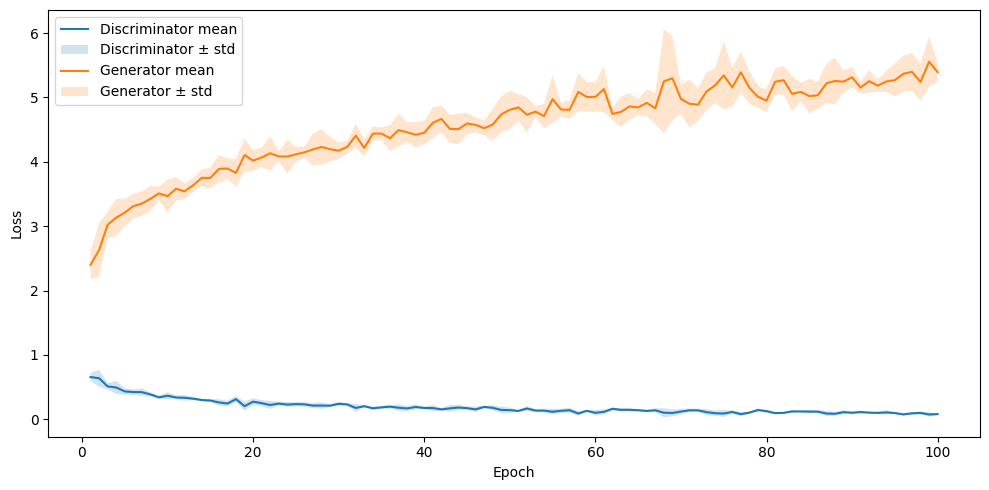

Saved plot to: Exp1/Exp1_loss_mean_std_4runs.png


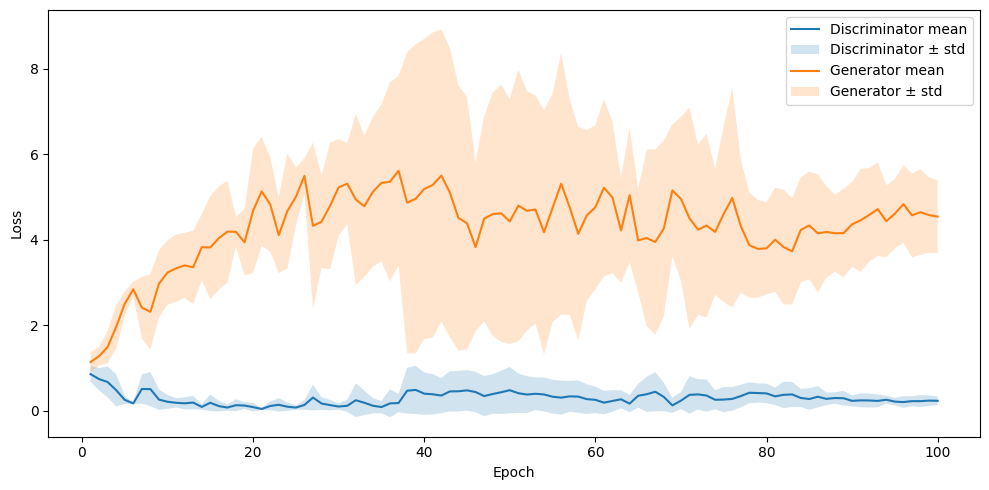

Saved plot to: Exp2/Exp2_loss_mean_std_4runs.png


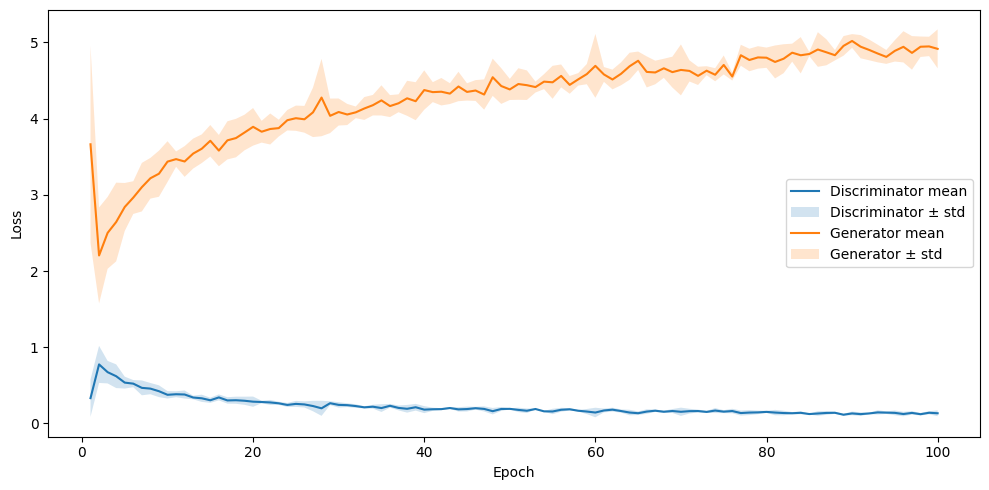

Saved plot to: Exp3/Exp3_loss_mean_std_4runs.png


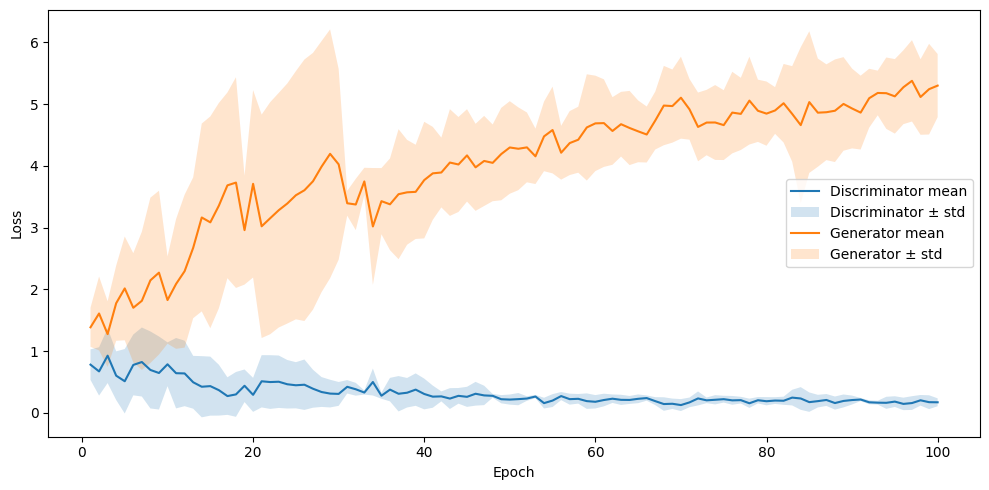

Saved plot to: Exp4/Exp4_loss_mean_std_4runs.png


In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
experiment_names = ["Exp1", "Exp2", "Exp3", "Exp4"]
seed_files = ["loss_seed_7.npz", "loss_seed_17.npz", "loss_seed_27.npz"] 

checkpoint_filename =  "original_run_losses.csv" #This is the checkpoint of the original run (First run without seeding)

num_epochs = 100

# =========================================================
# Load original losses from csv
# =========================================================
def load_original_losses_from_csv(csv_path, num_epochs):
    data = np.genfromtxt(csv_path, delimiter=",", names=True)

    if not {"epoch", "d_loss", "g_loss"}.issubset(data.dtype.names):
        raise KeyError(
            f"{csv_path} must contain columns: epoch, d_loss, g_loss. "
            f"Found columns: {data.dtype.names}"
        )

    d_epoch = np.array(data["d_loss"], dtype=np.float32)
    g_epoch = np.array(data["g_loss"], dtype=np.float32)

    if len(d_epoch) != num_epochs or len(g_epoch) != num_epochs:
        raise ValueError(
            f"{csv_path} has unexpected length: len(d_epoch)={len(d_epoch)}, "
            f"len(g_epoch)={len(g_epoch)}, expected {num_epochs}"
        )

    return d_epoch, g_epoch

# =========================================================
# Load one seed file (already epoch-wise)
# =========================================================
def load_seed_epoch_losses(npz_path):
    data = np.load(npz_path)

    if "d_ep" not in data or "g_ep" not in data:
        raise KeyError(
            f"{npz_path} does not contain 'd_ep' and 'g_ep'. Found keys: {data.files}"
        )

    d_ep = np.array(data["d_ep"], dtype=np.float32)
    g_ep = np.array(data["g_ep"], dtype=np.float32)

    return d_ep, g_ep

# =========================================================
# Load all 4 runs for one experiment
# =========================================================
def load_experiment_epoch_losses(exp_dir, checkpoint_filename, seed_files, num_epochs):
    checkpoint_path = os.path.join(exp_dir, f"{exp_dir}_"+checkpoint_filename)

    # original run from checkpoint
    orig_d_ep, orig_g_ep = load_original_losses_from_csv(checkpoint_path, num_epochs)

    all_d = [orig_d_ep]
    all_g = [orig_g_ep]

    # three seed runs from npz
    for sf in seed_files:
        npz_path = os.path.join(exp_dir, sf)
        d_ep, g_ep = load_seed_epoch_losses(npz_path)

        if len(d_ep) != num_epochs or len(g_ep) != num_epochs:
            raise ValueError(
                f"{npz_path} has unexpected length: len(d_ep)={len(d_ep)}, len(g_ep)={len(g_ep)}, expected {num_epochs}"
            )

        all_d.append(d_ep)
        all_g.append(g_ep)

    return np.stack(all_d, axis=0), np.stack(all_g, axis=0)  # shape: (4, num_epochs)

# =========================================================
# Plot one experiment
# =========================================================
def plot_mean_std_for_experiment(exp_name, exp_dir, checkpoint_filename, seed_files, num_epochs=100):
    all_d, all_g = load_experiment_epoch_losses(
        exp_dir=exp_dir,
        checkpoint_filename=checkpoint_filename,
        seed_files=seed_files,
        num_epochs=num_epochs
    )

    # mean ± std across 4 runs
    d_mean = all_d.mean(axis=0)
    d_std  = all_d.std(axis=0, ddof=1)

    g_mean = all_g.mean(axis=0)
    g_std  = all_g.std(axis=0, ddof=1)

    epochs = np.arange(1, num_epochs + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(epochs, d_mean, label="Discriminator mean")
    plt.fill_between(
        epochs,
        d_mean - d_std,
        d_mean + d_std,
        alpha=0.2,
        label="Discriminator ± std"
    )

    plt.plot(epochs, g_mean, label="Generator mean")
    plt.fill_between(
        epochs,
        g_mean - g_std,
        g_mean + g_std,
        alpha=0.2,
        label="Generator ± std"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    #plt.title(f"{exp_name}: Training Loss Curves Across 4 Runs")
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(exp_dir, f"{exp_name}_loss_mean_std_4runs.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {save_path}")

# =========================================================
# Run all experiments
# =========================================================
for exp_name in experiment_names:
    exp_dir = exp_name
    plot_mean_std_for_experiment(
        exp_name=exp_name,
        exp_dir=exp_dir,
        checkpoint_filename=checkpoint_filename,
        seed_files=seed_files,
        num_epochs=num_epochs
    )